# 1D Advection Solver with Higher Order Schemes

In [563]:
import numpy as np
import matplotlib.pyplot as plt

## Setup

### Domain Setup

Grid spacing (dx): 0.01
Time step size (dt): 0.005
Total simulation time (T): 1.0


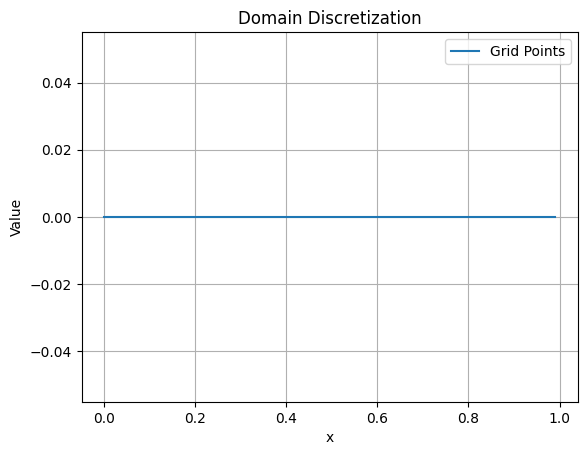

In [564]:
L = 1 # Length of the domain
N = 100 # Number of grid points

dx = L / N # Grid spacing

print("Grid spacing (dx):", dx)

x = np.linspace(0, L, N, endpoint=False)

c = 1.0
cfl = 0.5 # CFL number

dt = cfl * dx / c # Time step size
print("Time step size (dt):", dt)

nt = 200 # Number of time steps
T = nt * dt # Total simulation time
print("Total simulation time (T):", T)

plt.plot(x, np.zeros_like(x), label='Grid Points')
plt.title('Domain Discretization')
plt.xlabel('x')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

### INITIAL CONDITION: A Gaussian pulse

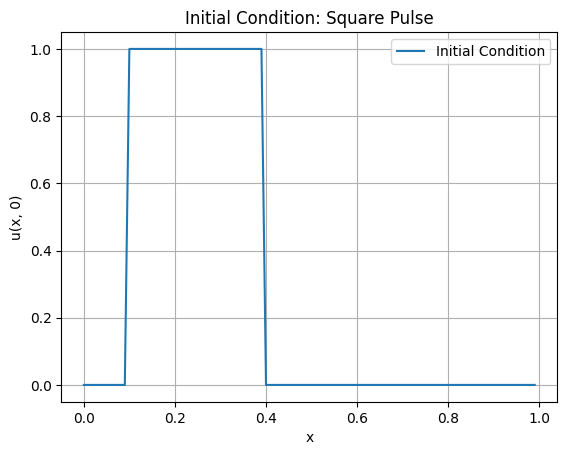

In [565]:
u0 = np.zeros_like(x)
u0[(x >= 0.1) & (x < 0.4)] = 1

plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Square Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()

### Solver: Upwind Scheme

In [566]:
def advection_ftbs(u, cfl):
    u_left  = np.roll(u, 1)   # u_{i-1} for all i, wraps u[0] → u[-1] (periodic BC)
    return u - cfl * (u - u_left)

u_upwind = np.copy(u0) # Initialize the solution with the initial condition
u_upwind_history = [u_upwind.copy()] # Store the solution history for plotting
for n in range(nt):
    u_upwind = advection_ftbs(u_upwind, cfl) # Update the solution using the FTBS scheme
    u_upwind_history.append(u_upwind.copy()) # Store the solution at each time step

### Result: Upwind Scheme

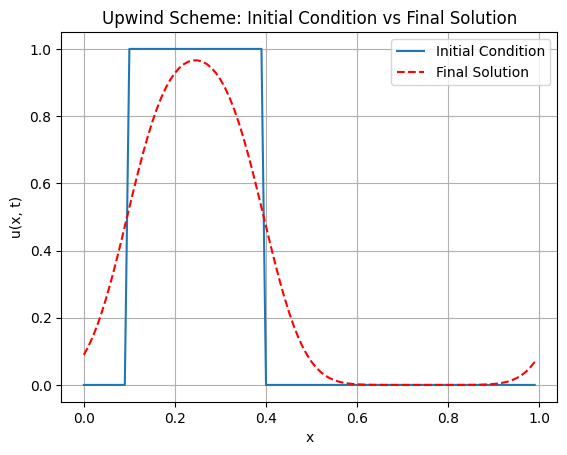

In [567]:
plt.plot(x, u0, label='Initial Condition')
plt.plot(x, u_upwind, label='Final Solution', linestyle='--', color='red')
plt.title('Upwind Scheme: Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

### Solver: TVD with minmod limiter

In [568]:
def minmod(r):
    return np.maximum(0, np.minimum(1, r))

def advection_tvd_minmod(u, cfl):
    u_ll = np.roll(u, 2)   # u_{i-2}
    u_left = np.roll(u, 1)   # u_{i-1}
    u_right = np.roll(u, -1)  # u_{i+1}

    r_right = (u - u_left) / (u_right - u + 1e-12)
    r_left = (u_left - u_ll)/ (u - u_left + 1e-12)

    phi_right = minmod(r_right)
    phi_left  = minmod(r_left)

    F_right = c * (u      + 0.5 * phi_right * (1 - cfl) * (u - u_left))
    F_left  = c * (u_left + 0.5 * phi_left  * (1 - cfl) * (u_left - u_ll))
    u_new = u - cfl * (F_right - F_left) / c

    return u_new

u_tvd_minmod = np.copy(u0) # Initialize the solution with the initial condition
u_tvd_minmod_history = [u_tvd_minmod.copy()] # Store the solution history for plotting
for n in range(nt):
    u_tvd_minmod = advection_tvd_minmod(u_tvd_minmod, cfl) # Update the solution using the TVD scheme with minmod limiter
    u_tvd_minmod_history.append(u_tvd_minmod.copy()) # Store the solution at each time step

### Result: TVD with minmod limiter

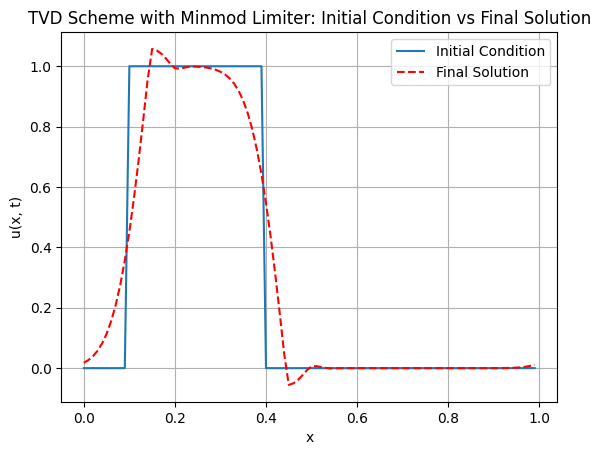

In [569]:
plt.plot(x, u0, label='Initial Condition')
plt.plot(x, u_tvd_minmod, label='Final Solution', linestyle='--', color='red')
plt.title('TVD Scheme with Minmod Limiter: Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

### Solver: TVD with Van Leer

In [570]:
def van_leer(r):
    return (r + np.abs(r)) / (1 + np.abs(r))

def advection_tvd_van_leer(u, cfl):
    u_ll = np.roll(u, 2)   # u_{i-2}
    u_left = np.roll(u, 1)   # u_{i-1}
    u_right = np.roll(u, -1)  # u_{i+1}

    r_right = (u - u_left) / (u_right - u + 1e-12)
    r_left = (u_left - u_ll)/ (u - u_left + 1e-12)

    phi_right = van_leer(r_right)
    phi_left  = van_leer(r_left)

    F_right = c * (u      + 0.5 * phi_right * (1 - cfl) * (u - u_left))
    F_left  = c * (u_left + 0.5 * phi_left  * (1 - cfl) * (u_left - u_ll))
    u_new = u - cfl * (F_right - F_left) / c
    return u_new

u_tvd_van_leer = np.copy(u0) # Initialize the solution with the initial condition
u_tvd_van_leer_history = [u_tvd_van_leer.copy()] # Store the solution history for plotting
for n in range(nt):
    u_tvd_van_leer = advection_tvd_van_leer(u_tvd_van_leer, cfl) # Update the solution using the TVD scheme with van Leer limiter
    u_tvd_van_leer_history.append(u_tvd_van_leer.copy()) # Store the solution at each time step

### Result: TVD with Van Leer

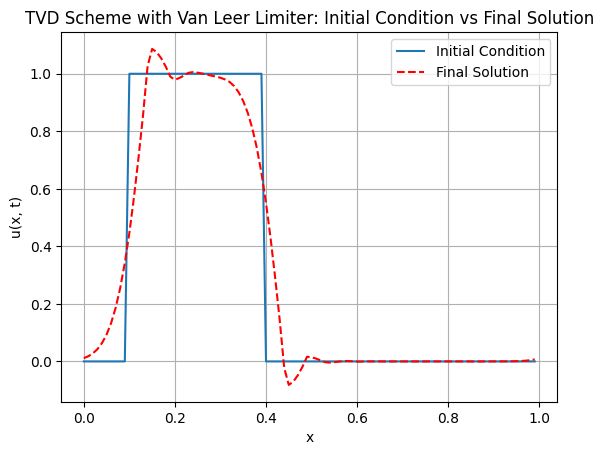

In [571]:
plt.plot(x, u0, label='Initial Condition')
plt.plot(x, u_tvd_van_leer, label='Final Solution', linestyle='--', color='red')
plt.title('TVD Scheme with Van Leer Limiter: Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

### Solver: TVD with superbee

In [572]:
def superbee(r):
    return np.maximum(0, np.maximum(np.minimum(2*r, 1), np.minimum(r, 2)))

def advection_tvd_superbee(u, cfl):
    u_ll = np.roll(u, 2)   # u_{i-2}
    u_left = np.roll(u, 1)   # u_{i-1}
    u_right = np.roll(u, -1)  # u_{i+1}

    r_right = (u - u_left) / (u_right - u + 1e-12)
    r_left = (u_left - u_ll)/ (u - u_left + 1e-12)

    phi_right = superbee(r_right)
    phi_left  = superbee(r_left)

    F_right = c * (u      + 0.5 * phi_right * (1 - cfl) * (u - u_left))
    F_left  = c * (u_left + 0.5 * phi_left  * (1 - cfl) * (u_left - u_ll))
    u_new = u - cfl * (F_right - F_left) / c
    return u_new

u_tvd_superbee = np.copy(u0) # Initialize the solution with the initial condition
u_tvd_superbee_history = [u_tvd_superbee.copy()] # Store the solution history for plotting
for n in range(nt):
    u_tvd_superbee = advection_tvd_superbee(u_tvd_superbee, cfl) # Update the solution using the TVD scheme with superbee limiter
    u_tvd_superbee_history.append(u_tvd_superbee.copy()) # Store the solution at each time step

### Result: TVD with superbee

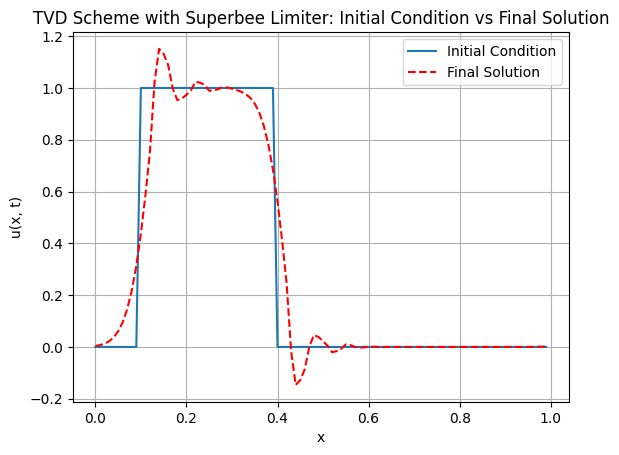

In [573]:
plt.plot(x, u0, label='Initial Condition')
plt.plot(x, u_tvd_superbee, label='Final Solution', linestyle='--', color='red')
plt.title('TVD Scheme with Superbee Limiter: Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

### Solver: TVD with MC

In [574]:
def mc(r):
    return np.maximum(0, np.minimum((1 + r) / 2, np.minimum(2, 2 * r)))

def advection_tvd_mc(u, cfl):
    u_ll = np.roll(u, 2)   # u_{i-2}
    u_left = np.roll(u, 1)   # u_{i-1}
    u_right = np.roll(u, -1)  # u_{i+1}

    r_right = (u - u_left) / (u_right - u + 1e-12)
    r_left = (u_left - u_ll)/ (u - u_left + 1e-12)

    phi_right = mc(r_right)
    phi_left  = mc(r_left)

    F_right = c * (u      + 0.5 * phi_right * (1 - cfl) * (u - u_left))
    F_left  = c * (u_left + 0.5 * phi_left  * (1 - cfl) * (u_left - u_ll))
    u_new = u - cfl * (F_right - F_left) / c
    return u_new

u_tvd_mc = np.copy(u0) # Initialize the solution with the initial condition
u_tvd_mc_history = [u_tvd_mc.copy()] # Store the solution history for plotting
for n in range(nt):
    u_tvd_mc = advection_tvd_mc(u_tvd_mc, cfl) # Update the solution using the TVD scheme with MC limiter
    u_tvd_mc_history.append(u_tvd_mc.copy()) # Store the solution at each time step

### Result: TVD with MC

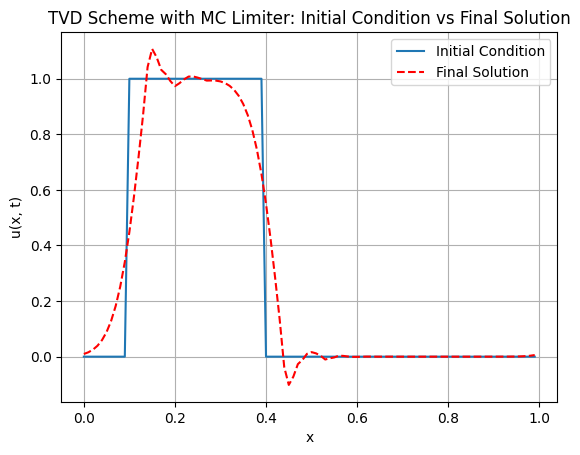

In [575]:
plt.plot(x, u0, label='Initial Condition')
plt.plot(x, u_tvd_mc, label='Final Solution', linestyle='--', color='red')
plt.title('TVD Scheme with MC Limiter: Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

### Overall Plot

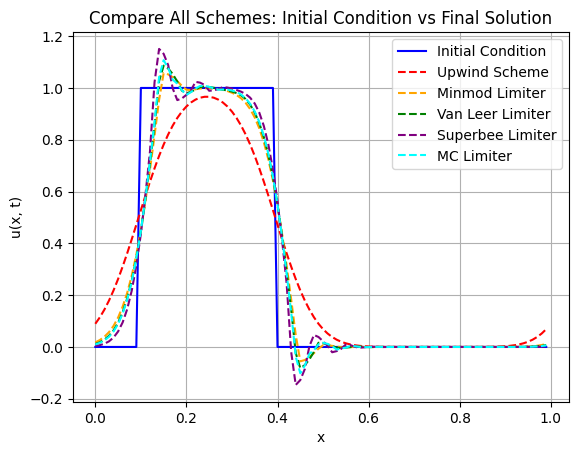

In [576]:
plt.plot(x, u0, label='Initial Condition', color='blue')
plt.plot(x, u_upwind, label='Upwind Scheme', linestyle='--', color='red')
plt.plot(x, u_tvd_minmod, label='Minmod Limiter', linestyle='--', color='orange')
plt.plot(x, u_tvd_van_leer, label='Van Leer Limiter', linestyle='--', color='green')
plt.plot(x, u_tvd_superbee, label='Superbee Limiter', linestyle='--', color='purple')
plt.plot(x, u_tvd_mc, label='MC Limiter', linestyle='--', color='cyan')
plt.title('Compare All Schemes: Initial Condition vs Final Solution')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()

### L2 Error

In [577]:
# L2 error calculation
def l2_error(u_numeric, u_exact):
    return np.sqrt(np.sum((u_numeric - u_exact) ** 2) * dx)

schemes = {
    'Upwind': u_upwind,
    'Minmod Limiter': u_tvd_minmod,
    'Van Leer Limiter': u_tvd_van_leer,
    'Superbee Limiter': u_tvd_superbee,
    'MC Limiter': u_tvd_mc
}

u_exact = u0 # The exact solution at t=T is the same as the initial condition due to periodic BC and advection

for name, u_numeric in schemes.items():
    error = l2_error(u_numeric, u_exact)
    print(f'L2 Error for {name}: {error:.6f}')

L2 Error for Upwind: 0.181747
L2 Error for Minmod Limiter: 0.136519
L2 Error for Van Leer Limiter: 0.131687
L2 Error for Superbee Limiter: 0.125132
L2 Error for MC Limiter: 0.130282


### Overshoot and Undershhot

In [580]:
overshoot_upwind = np.max(u_upwind) - 1
overshoot_minmod = np.max(u_tvd_minmod) - 1
overshoot_van_leer = np.max(u_tvd_van_leer) - 1
overshoot_superbee = np.max(u_tvd_superbee) - 1
overshoot_mc = np.max(u_tvd_mc) - 1

undershoot_upwind = np.min(u_upwind)
undershoot_minmod = np.min(u_tvd_minmod)
undershoot_van_leer = np.min(u_tvd_van_leer)
undershoot_superbee = np.min(u_tvd_superbee)
undershoot_mc = np.min(u_tvd_mc)

# sort schemes by L2 error
sorted_schemes = sorted(schemes.items(), key=lambda item: l2_error(item[1], u_exact))
print("\nSchemes sorted by L2 error:")
for name, _ in sorted_schemes:
    error = l2_error(schemes[name], u_exact)
    print(f"{name:<20}: {error:.6f}")

# sort schemes by overshoot
sorted_overshoot = sorted(schemes.items(), key=lambda item: np.max(item[1]) - 1)
print("\nSchemes sorted by overshoot:")
for name, _ in sorted_overshoot:
    overshoot = np.max(schemes[name]) - 1
    print(f"{name:<20}: {overshoot:.6f}")

# sort schemes by undershoot
sorted_undershoot = sorted(schemes.items(), key=lambda item: np.min(item[1]))
print("\nSchemes sorted by undershoot:")
for name, _ in sorted_undershoot[::-1]: # reverse to show most negative undershoot first
    undershoot = np.min(schemes[name])
    print(f"{name:<20}: {undershoot:.6f}")


Schemes sorted by L2 error:
Superbee Limiter    : 0.125132
MC Limiter          : 0.130282
Van Leer Limiter    : 0.131687
Minmod Limiter      : 0.136519
Upwind              : 0.181747

Schemes sorted by overshoot:
Upwind              : -0.034081
Minmod Limiter      : 0.057393
Van Leer Limiter    : 0.086346
MC Limiter          : 0.107302
Superbee Limiter    : 0.150695

Schemes sorted by undershoot:
Upwind              : 0.000001
Minmod Limiter      : -0.055573
Van Leer Limiter    : -0.081733
MC Limiter          : -0.101657
Superbee Limiter    : -0.146612
